In [1]:
import pandas as pd
df = pd.read_csv('/home/davian/Projects/ML-DL-LAB/ml/regression/data/raw/BostonHousing.csv')

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [3]:
from preprocessing.cleaning import limpieza
from preprocessing.split_data import dividir_datos
from src.config import TARGET

df = limpieza(df)
x_train, x_test, y_train, y_test = dividir_datos(df, target=TARGET)

In [4]:
from preprocessing.pipeline import estandarizar

x_train, x_test, _ = estandarizar(x_train, x_test)

### A.- Mejor modelo

In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


models = {
    'linear': LinearRegression(),
    'ridge': Ridge(),
    'lasso': Lasso(),
    'Bayesian': BayesianRidge(),
    'tree': DecisionTreeRegressor(),
    'forest':RandomForestRegressor(),
    'knn': KNeighborsRegressor(),
    'gradient': GradientBoostingRegressor()
}

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    pred = model.predict(x_test)

    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append({'model': name, 'mse': mse, 'mae': mae, 'r2': r2})

In [7]:
results_df = pd.DataFrame(data=results)

In [8]:
results_df

,model,mse,mae,r2
0,linear,20.687720,3.242857,0.720028
1,ridge,20.658202,3.241298,0.720427
2,lasso,24.307228,3.749697,0.671044
3,Bayesian,20.546123,3.234162,0.721944
4,tree,19.550990,3.004950,0.735411
5,forest,9.275534,2.301970,0.874472
6,knn,11.851505,2.484950,0.839611
7,gradient,7.626020,2.143666,0.896795


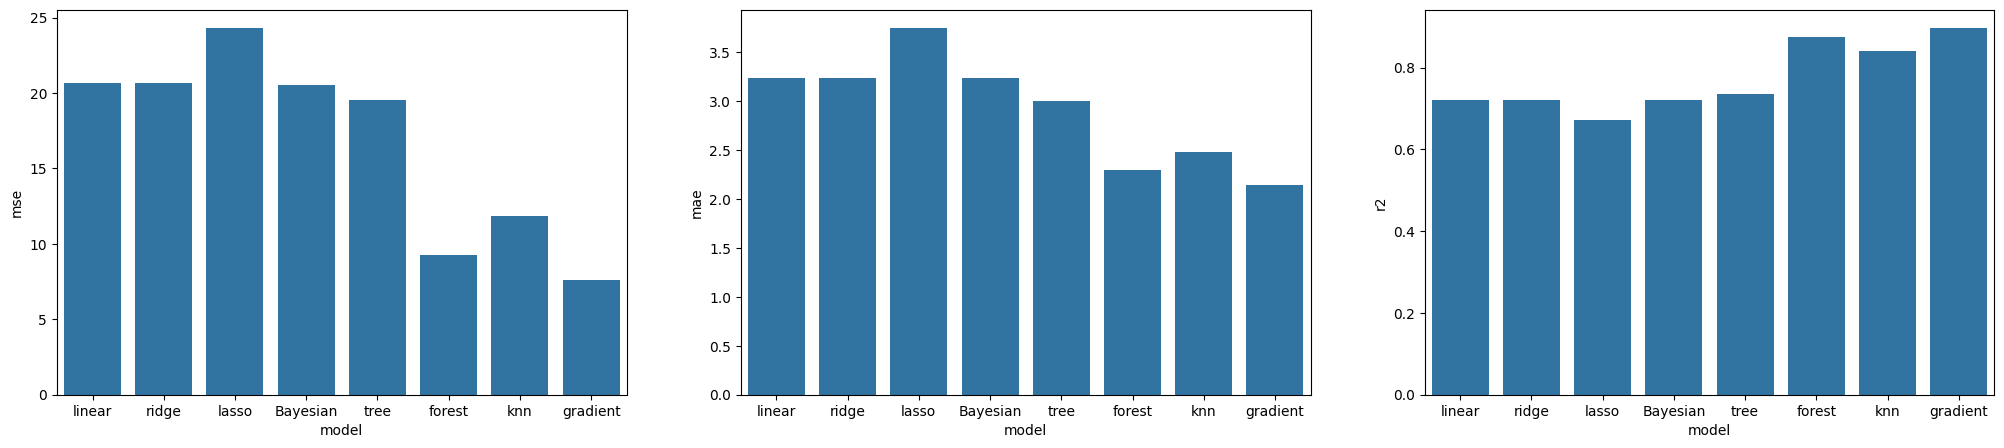

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(25, 5))

metrics = ['mse', 'mae', 'r2']

for i, metric in enumerate(metrics, start=1):
    plt.subplot(1, 3, i)
    sns.barplot(data=results_df, x='model', y=metric)

La mejor es gradient con el r2 mas alto y el mse y mae mas bajos

### B.- Mejor hiperparametro

In [10]:
hipermatros = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
}

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GridSearchCV(estimator=GradientBoostingRegressor(), param_grid=hipermatros, cv=5)

gb_model.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter cand

In [12]:
gb_model.best_params_

{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

### C.-  Evaluación

In [13]:
y_pred = gb_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('mse:', mse, '\nmae:', mae, '\nr2:', r2)

mse: 7.3561444557092015 
mae: 2.0155988186802727 
r2: 0.9004474086013119


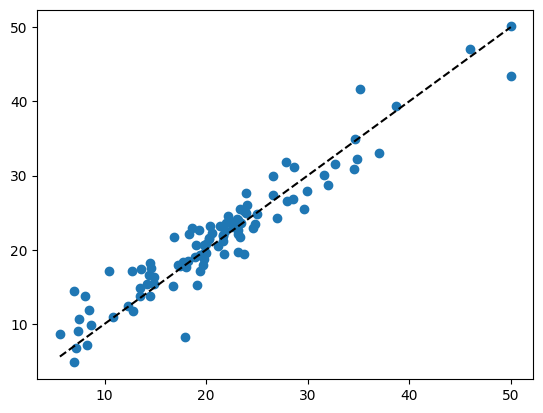

In [14]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')

In [15]:
error = y_test - y_pred

<Axes: xlabel='Precio', ylabel='Count'>

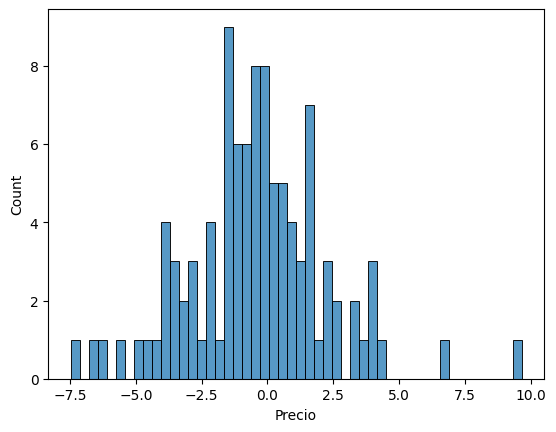

In [16]:
sns.histplot(error, bins=50)